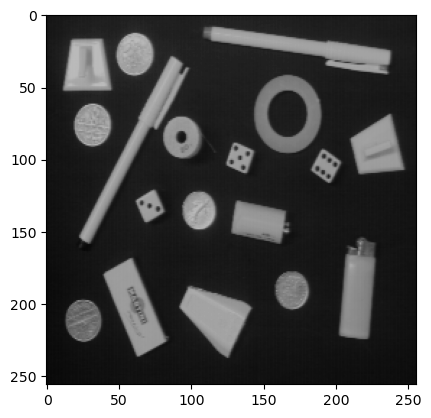

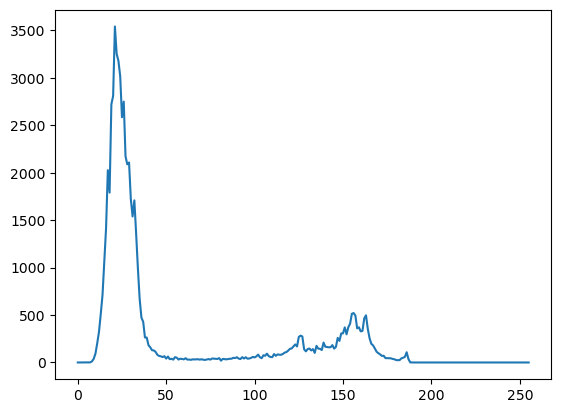

In [37]:
import cv2
import matplotlib.pyplot as plt

objects = cv2.imread('OBJECTS.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(objects, cmap='gray', vmin=0, vmax=255)
plt.show()
histO = cv2.calcHist([objects],[0],None,[256],[0,256])
plt.plot(histO)
plt.show()


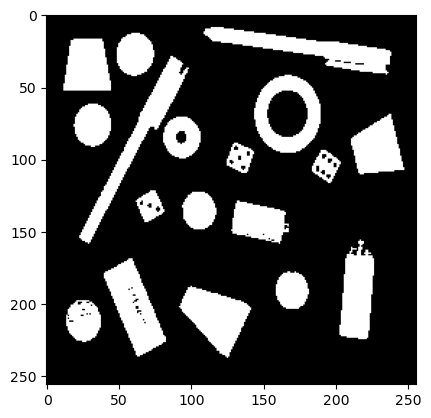

In [38]:
umbralGO = 90  # Puedes ajustar este valor según la imagen
_, objectsUG = cv2.threshold(objects, umbralGO, 255, cv2.THRESH_BINARY)
plt.imshow(objectsUG, cmap='gray', vmin=0, vmax=255)
plt.show()


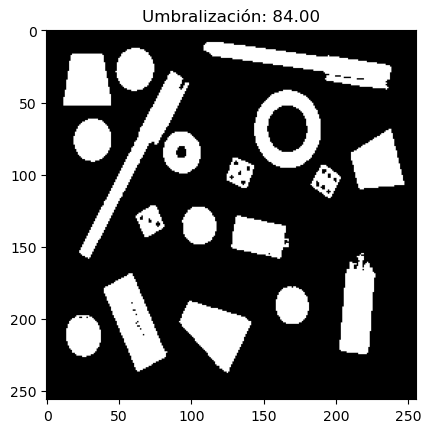

In [39]:
umbralOO, objectsUO = cv2.threshold(objects, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(objectsUO, cmap='gray', vmin=0, vmax=255)
plt.title(f"Umbralización: {umbralOO:.2f}")
plt.show()


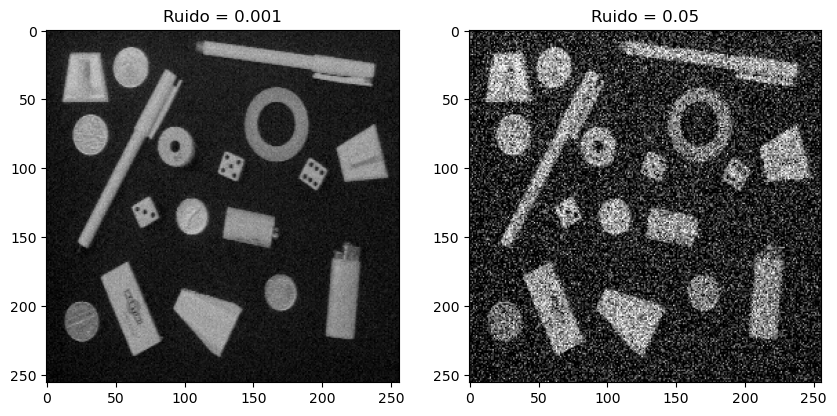

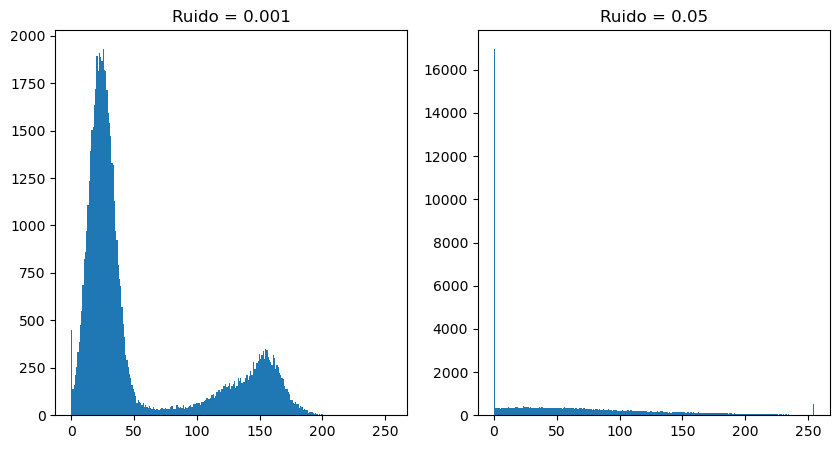

In [40]:
import numpy as np
from skimage.util import random_noise

objectsN1 = random_noise(objects, mode='gaussian', mean=0, var=0.001)
objectsN1 = (objectsN1 * 255).astype(np.uint8) 
objectsN5 = random_noise(objects, mode='gaussian', mean=0, var=0.05)
objectsN5 = (objectsN5 * 255).astype(np.uint8)


plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(objectsN1, cmap='gray', vmin=0, vmax=255)
plt.title("Ruido = 0.001")
plt.subplot(1,2,2)
plt.imshow(objectsN5, cmap='gray', vmin=0, vmax=255)
plt.title("Ruido = 0.05")
plt.show()

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(objectsN1.ravel(), bins=256, range=[0,255])
plt.title("Ruido = 0.001")
plt.subplot(1,2,2)
plt.hist(objectsN5.ravel(), bins=256, range=[0,255])
plt.title("Ruido = 0.05")
plt.show()


### ¿Qué sucede? ¿Por qué sucede esto?
Cuando le agregamos poco ruido (0.001) a la imágen, el cambio es apenas perceptible y lo que veremos es que esta se va a ver levemente granulada. Sin embargo, el cambio se va a notar mucho al analizar el histograma, ya que si lo comparamos con el de la imagen original, vamos a ver que el area bajo la curva está coloreada (esto representa el leve granulado en la imágen). Por otro lado, cuando el ruido es más alto (0.05) la alteración en la imagen es mucho más notoria, el granulado hace que ya no se puedan distinguir las los objetos de la imágen original. También podemos ver que el histograma muestra una mayor dispersión con valores más extendidos y la forma de la curva es totalmente diferente.

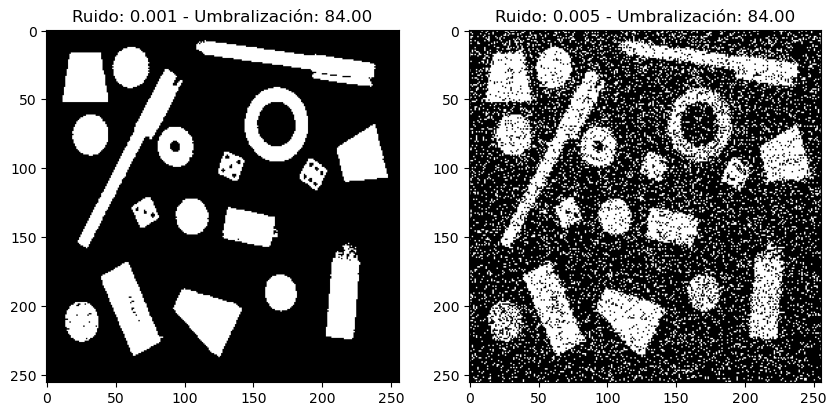

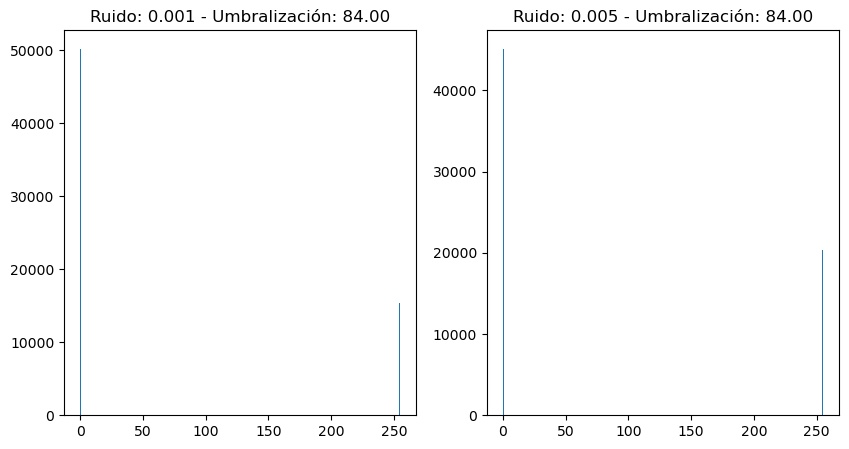

In [41]:
umbralOO1, objectsUO1 = cv2.threshold(objectsN1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
umbralOO5, objectsUO5 = cv2.threshold(objectsN5, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(objectsUO1, cmap='gray', vmin=0, vmax=255)
plt.title(f"Ruido: 0.001 - Umbralización: {umbralOO1:.2f}")
plt.subplot(1,2,2)
plt.imshow(objectsUO5, cmap='gray', vmin=0, vmax=255)
plt.title(f"Ruido: 0.005 - Umbralización: {umbralOO5:.2f}")
plt.show()

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(objectsUO1.ravel(), bins=256, range=[0,255])
plt.title(f"Ruido: 0.001 - Umbralización: {umbralOO1:.2f}")
plt.subplot(1,2,2)
plt.hist(objectsUO5.ravel(), bins=256, range=[0,255])
plt.title(f"Ruido: 0.005 - Umbralización: {umbralOO5:.2f}")
plt.show()


### ¿Cómo afecta el ruido al resultado? 

Para la imagen con poco ruido, la umbralización Otsu encuentra un valor adecuado, se ve casi igual a la umbralización de la imagen original. En cuanto al histograma, podemos ver que solo existen valores en 255 que representan los objetos y en 0 que representan el fondo.Para la imagen com mucho ruido, la umbralización Otsu falla a la hora de encontrar un valor adecuado, lo que sucede es que el granulado de la imagen se hace más evidente y también distorciona los objetos. En cuanto al histograma, igual podemos ver valores solo en 0 para el fondo pero también sube la cantidad de pixeles en 255 porque algunas secciones del granulado estaban muy claras y se colan en la parte de resaltación de la umbralización.

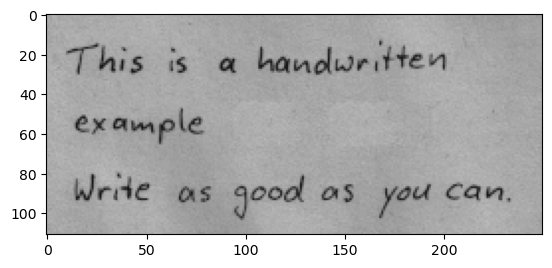

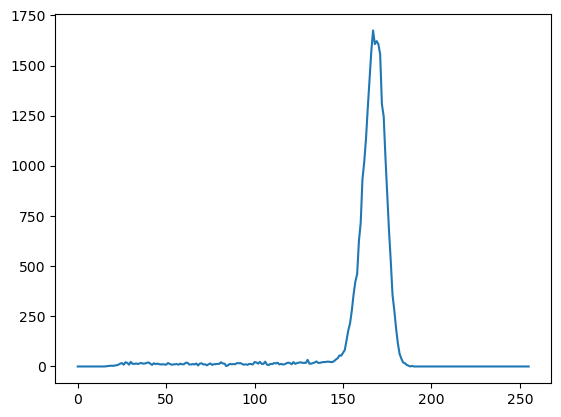

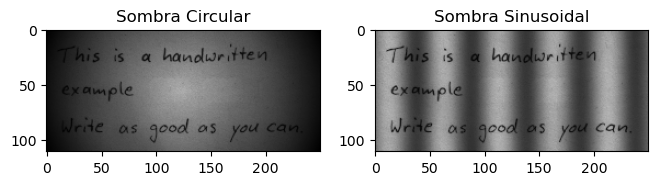

In [42]:
text = cv2.imread('TEXT.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(text, cmap='gray', vmin=0, vmax=255)
plt.show()
histT = cv2.calcHist([text],[0],None,[256],[0,256])
plt.plot(histT)
plt.show()

rows, cols = text.shape
x, y = np.meshgrid(np.arange(cols), np.arange(rows))
cx, cy = cols // 2, rows // 2
distance = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
max_dist = np.sqrt(cx**2 + cy**2)
spot_shading = 1 - (distance / max_dist)
spot_image = (text * spot_shading).astype(np.uint8)


frequency = 50
amplitude = 0.5
sinusoidal_shading = (1 + amplitude * np.sin(2 * np.pi * x / frequency)) / 1.5
sinusoidal_image = (text * sinusoidal_shading).astype(np.uint8)


plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 2)
plt.imshow(spot_image, cmap='gray', vmin=0, vmax=255)
plt.title("Sombra Circular")
plt.subplot(1, 3, 3)
plt.imshow(sinusoidal_image, cmap='gray', vmin=0, vmax=255)
plt.title("Sombra Sinusoidal")
plt.show()



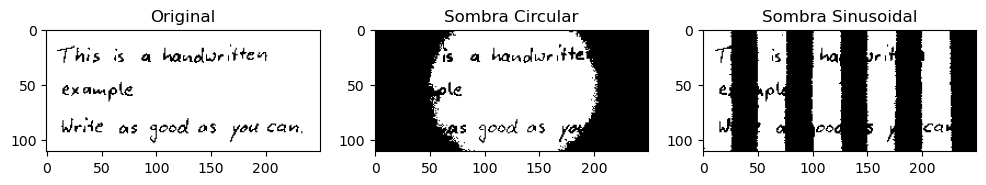

In [43]:
_, textUO = cv2.threshold(text, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, circularUO = cv2.threshold(spot_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, sinusoidalUO = cv2.threshold(sinusoidal_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1), plt.imshow(textUO, cmap='gray'), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(circularUO, cmap='gray'), plt.title("Sombra Circular")
plt.subplot(1,3,3), plt.imshow(sinusoidalUO, cmap='gray'), plt.title("Sombra Sinusoidal")
plt.show()


### ¿Qué sucede? ¿Por qué sucede esto? ¿Qué alternativas puede emplear para mitigar este resultado?

Las sombras alteran la distribución del histograma, entonces el efecto de la sombra puede lo que puede llevar al algoritmo Otsu a seleccionar un umbral inadecuado y segmentar incorrectamente las regiones claras y oscuras en las que se quiere diferenciar las letras del papel. Para mitigar este problema, se pueden aplicar técnicas de corrección de iluminación, como cv2.equalizeHist() o CLAHE, que mejoran el contraste antes de la umbralización. Otra alternativa es el umbral adaptativo, que analiza las propiedades locales de la imagen en lugar de aplicar un único umbral global, premitiendo segmentar correctamente dependiedo del contraste que existe en cada sección de la imagen.

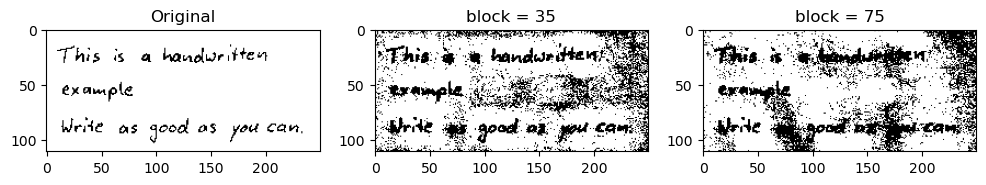

In [44]:
from skimage.filters import threshold_local

block_size1 = 35
block_size2 = 75

ti1 = threshold_local(text, block_size=block_size1, method='mean')
img_adapt1 = (text > ti1).astype(np.uint8) * 255
ti2 = threshold_local(text, block_size=block_size2, method='mean')
img_adapt2 = (text > ti2).astype(np.uint8) * 255

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.imshow(textUO, cmap='gray', vmin=0, vmax=255)
plt.title(f"Original")
plt.subplot(1,3,2)
plt.imshow(img_adapt1, cmap='gray', vmin=0, vmax=255)
plt.title(f"block = {block_size1}")
plt.subplot(1,3,3)
plt.imshow(img_adapt2, cmap='gray', vmin=0, vmax=255)
plt.title(f"block = {block_size2}")
plt.show()


### ¿En qué cambia el resultado con relación al método de Otsu? ¿Qué implicaciones tiene esto? ¿Cómo puede mejorar el resultado de la segmentación para reducir el ruido en ambos casos?

El umbral adaptativo mejora la segmentación cuando existen sombras y variaciones de iluminación en la imagen, pero su efectividad depende del tamaño del bloque empleado. Los bloques pequeños capturan más detalles pero pueden verse más afectados por el ruido, mientras que los bloques grandes no se afectan por el granulado pero pueden perder bordes importantes. Para reducir el ruido y mejorar la segmentación, se pueden aplicar filtros como cv2.GaussianBlur o cv2.medianBlu antes de la umbralización. Además, combinar el método Otsu para una segmentación inicial y umbral adaptativo para refinar los resultados puede generar un mejor resultado.